In [71]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import os
import pandas as pd
import gc
from pathlib import Path
import netCDF4 as nc
from datetime import datetime
import re

In [72]:
gemlam_dir = "/results/forcing/atmospheric/GEM2.5/gemlam"
operational_dir = "/results/forcing/atmospheric/GEM2.5/operational"
time_fixed_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/TimeFixed"

gemlam_start = datetime(2007, 1, 3)
gemlam_end = datetime(2014, 9, 30)
ops_start = datetime(2014, 10, 1)
ops_end = datetime(2021, 12, 31)

years = range(2007, 2022)

fixed_2008_filenames = {
    "gemlam_y2008m07d16.nc",
    "gemlam_y2008m07d17.nc",
    "gemlam_y2008m07d18.nc",
    "gemlam_y2008m07d19.nc",
    "gemlam_y2008m07d20.nc",
    "gemlam_y2008m07d21.nc",
    "gemlam_y2008m07d22.nc",
    "gemlam_y2008m07d23.nc",
    "gemlam_y2008m08d10.nc",
    "gemlam_y2008m08d11.nc",
    "gemlam_y2008m08d12.nc",
}

def get_file_date(filepath):
    filename = os.path.basename(filepath)
    match = re.search(r"_y(\d{4})m(\d{2})d(\d{2})", filename)
    if match is None:
        return None
    year, month, day = map(int, match.groups())
    return datetime(year, month, day)

all_gemlam_files = glob.glob(os.path.join(gemlam_dir, "*.nc"))
all_ops_files = glob.glob(os.path.join(operational_dir, "ops_y????m??d??.nc"))

selected_gemlam_files = {}

for filepath in all_gemlam_files:
    file_date = get_file_date(filepath)
    if file_date is not None and gemlam_start <= file_date <= gemlam_end:
        selected_gemlam_files[file_date] = filepath

for filename in fixed_2008_filenames:
    fixed_filepath = os.path.join(time_fixed_dir, filename)
    if not os.path.exists(fixed_filepath):
        raise FileNotFoundError(f"Corrected file not found: {fixed_filepath}")
    fixed_date = get_file_date(fixed_filepath)
    if fixed_date is None:
        raise ValueError(f"Could not extract date from: {fixed_filepath}")
    selected_gemlam_files[fixed_date] = fixed_filepath

selected_ops_files = {}

for filepath in all_ops_files:
    file_date = get_file_date(filepath)
    if file_date is not None and ops_start <= file_date <= ops_end:
        selected_ops_files[file_date] = filepath

all_selected_files = {**selected_gemlam_files, **selected_ops_files}

hrdps_files_by_year = {}

for year in years:
    files = [filepath for file_date, filepath in sorted(all_selected_files.items()) if file_date.year == year]
    if len(files) == 0:
        print(f"{year}: no files found")
        continue
    hrdps_files_by_year[year] = files
    print(year, ":", files[0], "to", files[-1], f"({len(files)} files)")

2007 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d03.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m12d31.nc (363 files)
2008 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m12d31.nc (366 files)
2009 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m12d31.nc (365 files)
2010 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m12d31.nc (365 files)
2011 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m12d31.nc (365 files)
2012 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m12d31.nc (366 files)
2013 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2013m01d01.nc to /results/forc

In [73]:
# Loading datasets

weights_pre_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc"
weights_post_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_22sep11onward.nc"
mesh_mask_file = "/ocean/dtaneja/MOAD/analysis-dishika/grid/mesh_mask202108.nc"

ds_weights_pre = xr.open_dataset(weights_pre_file).load()
ds_weights_post = xr.open_dataset(weights_post_file).load()

with xr.open_dataset(mesh_mask_file) as ds_mesh:
    nemo_lat = ds_mesh["nav_lat"].load()
    nemo_lon = ds_mesh["nav_lon"].load()

In [74]:
# Converts hourly HRDPS temperature from the 266 × 256 HRDPS grid to the 898 × 398 NEMO grid

transition_time = pd.Timestamp("2011-09-22 00:00:00")

def interpolate_atmpres_with_weights(atmpres, ds_weights):
    atmpres = atmpres.transpose("time_counter", "y", "x")

    n_time = atmpres.sizes["time_counter"]
    source_shape = (atmpres.sizes["y"],atmpres.sizes["x"])
    n_source_cells = source_shape[0] * source_shape[1]

    source_values = (atmpres.values.reshape(n_time, n_source_cells).astype(np.float32))
    target_shape = ds_weights["src01"].shape

    interpolated = np.zeros((n_time, target_shape[0], target_shape[1]),dtype=np.float32)

    for n in range(1, 5):
        # The source indexes in the weights file are 1-based
        source_index = (ds_weights[f"src{n:02d}"].values.astype(np.int64)- 1)
        weight = (ds_weights[f"wgt{n:02d}"].values.astype(np.float32))

        interpolated += (source_values[:, source_index]* weight[None, :, :])

    atmpres_nemo = xr.DataArray(
        interpolated,
        dims=("time_counter", "y", "x"),
        coords={
            "time_counter": atmpres["time_counter"],
            "nav_lat": (("y", "x"), nemo_lat.values),
            "nav_lon": (("y", "x"), nemo_lon.values),
        },
        name="atmpres"
    )

    atmpres_nemo.attrs = atmpres.attrs.copy()
    atmpres_nemo.attrs["grid"] = "SalishSeaCast NEMO grid"
    atmpres_nemo.attrs["interpolation"] = (
        "Four-source weighted HRDPS-to-NEMO interpolation"
    )
    return atmpres_nemo

In [75]:
# Open file and interpolates

def extract_and_interpolate_hourly_atmpres(file):
    with xr.open_dataset(file) as ds:
        atmpres = ds["atmpres"].sortby("time_counter")
        time_index = atmpres.get_index("time_counter")

        if time_index.has_duplicates:
            unique_mask = ~time_index.duplicated()
            atmpres = atmpres.isel(time_counter=unique_mask)

        atmpres = atmpres.load()

    times = pd.to_datetime(atmpres["time_counter"].values)

    before_transition = times < transition_time
    after_transition = times >= transition_time

    pieces = []

    if before_transition.any():
        atmpres_pre = atmpres.isel(time_counter=np.where(before_transition)[0])
        interpolated_pre = interpolate_atmpres_with_weights(atmpres_pre,ds_weights_pre)
        pieces.append(interpolated_pre)

    if after_transition.any():
        atmpres_post = atmpres.isel(time_counter=np.where(after_transition)[0])
        interpolated_post = interpolate_atmpres_with_weights(atmpres_post,ds_weights_post)
        pieces.append(interpolated_post)

    atmpres_nemo = xr.concat(pieces,dim="time_counter").sortby("time_counter")
    return atmpres_nemo

In [76]:
sample_pre_file = hrdps_files_by_year[2008][0]
atmpres_nemo_pre = extract_and_interpolate_hourly_atmpres(sample_pre_file)

print("Shape:", atmpres_nemo_pre.shape)
print("Time range:",atmpres_nemo_pre.time_counter.values[0],"to",atmpres_nemo_pre.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2008-01-01T00:00:00.000000000 to 2008-01-01T23:00:00.000000000


In [77]:
sample_post_file = hrdps_files_by_year[2012][0]
atmpres_nemo_post = extract_and_interpolate_hourly_atmpres(sample_post_file)

print("Shape:", atmpres_nemo_post.shape)
print("Time range:",atmpres_nemo_post.time_counter.values[0],"to",atmpres_nemo_post.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2012-01-01T00:00:00.000000000 to 2012-01-01T23:00:00.000000000


In [78]:
sample_post_file = hrdps_files_by_year[2015][0]
atmpres_nemo_post = extract_and_interpolate_hourly_atmpres(sample_post_file)

print("Shape:", atmpres_nemo_post.shape)
print("Time range:",atmpres_nemo_post.time_counter.values[0],"to",atmpres_nemo_post.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2015-01-01T00:00:00.000000000 to 2015-01-01T23:00:00.000000000


In [79]:
sample_post_file = hrdps_files_by_year[2021][-1]
atmpres_nemo_post = extract_and_interpolate_hourly_atmpres(sample_post_file)

print("Shape:", atmpres_nemo_post.shape)
print("Time range:",atmpres_nemo_post.time_counter.values[0],"to",atmpres_nemo_post.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2021-12-31T00:00:00.000000000 to 2021-12-31T23:00:00.000000000


In [80]:
with xr.open_dataset(mesh_mask_file) as ds_mesh:
    water_mask = (ds_mesh["tmask"].isel(t=0, z=0).load().values.astype(bool))
    nemo_lat_2d = ds_mesh["nav_lat"].load().values
    nemo_lon_2d = ds_mesh["nav_lon"].load().values
nemo_j, nemo_i = np.where(water_mask)
water_flat_indices = np.flatnonzero(water_mask.reshape(-1))
nemo_water_lat = nemo_lat_2d[water_mask]
nemo_water_lon = nemo_lon_2d[water_mask]
n_water = len(water_flat_indices)
print("NEMO grid shape:", water_mask.shape)
print("Number of surface water cells:", n_water)

NEMO grid shape: (898, 398)
Number of surface water cells: 81383


In [81]:
def process_daily_file_to_3h_water(file):
    atmpres_nemo_hourly = extract_and_interpolate_hourly_atmpres(file)
    n_time = atmpres_nemo_hourly.sizes["time_counter"]

    atmpres_water_values = (atmpres_nemo_hourly.values.reshape(n_time, -1)[:, water_flat_indices].astype(np.float32))
    atmpres_water_hourly = xr.DataArray(atmpres_water_values,dims=("time_counter", "water_cell"),coords={
            "time_counter": atmpres_nemo_hourly["time_counter"].values,
            "water_cell": np.arange(n_water, dtype=np.int32),},name="atmpres",attrs=atmpres_nemo_hourly.attrs,)

    atmpres_water_3h = atmpres_water_hourly.resample(time_counter="3h",label="left",closed="left",origin="start_day",).mean()
    return atmpres_water_3h.load()

In [82]:
test_file = hrdps_files_by_year[2008][0]

test_3h = process_daily_file_to_3h_water(test_file)

print(test_3h)
print("Shape:", test_3h.shape)
print("Times:", test_3h.time_counter.values)

<xarray.DataArray 'atmpres' (time_counter: 8, water_cell: 81383)> Size: 3MB
array([[103206.9  , 103207.22 , 103207.555, ..., 103486.97 , 103486.23 ,
        103485.48 ],
       [102985.41 , 102985.195, 102985.   , ..., 103464.88 , 103463.87 ,
        103462.77 ],
       [102746.125, 102746.336, 102746.5  , ..., 103199.23 , 103197.88 ,
        103196.48 ],
       ...,
       [102096.98 , 102096.65 , 102096.32 , ..., 102307.71 , 102305.19 ,
        102302.6  ],
       [101967.06 , 101966.85 , 101966.625, ..., 101952.6  , 101949.94 ,
        101947.21 ],
       [101739.69 , 101739.4  , 101739.1  , ..., 101558.93 , 101556.54 ,
        101554.15 ]], shape=(8, 81383), dtype=float32)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64B 2008-01-01 ... 2008-01-01...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
Attributes:
    level:          mean sea level
    long_name:      Pressure Reduced to MSL
    standard_name:  air_pressure_at_sea_level
  

In [83]:
test_file = hrdps_files_by_year[2015][0]

test_3h = process_daily_file_to_3h_water(test_file)

print(test_3h)
print("Shape:", test_3h.shape)
print("Times:", test_3h.time_counter.values)

<xarray.DataArray 'atmpres' (time_counter: 8, water_cell: 81383)> Size: 3MB
array([[103229.98 , 103230.19 , 103230.414, ..., 103213.57 , 103212.414,
        103211.29 ],
       [103161.44 , 103161.375, 103161.35 , ..., 103129.445, 103127.29 ,
        103125.19 ],
       [103037.15 , 103037.12 , 103037.12 , ..., 103023.5  , 103021.81 ,
        103020.15 ],
       ...,
       [102664.06 , 102664.15 , 102664.23 , ..., 102584.23 , 102584.19 ,
        102584.125],
       [102660.81 , 102660.836, 102660.87 , ..., 102554.63 , 102554.19 ,
        102553.75 ],
       [102500.35 , 102500.34 , 102500.31 , ..., 102407.164, 102406.04 ,
        102404.9  ]], shape=(8, 81383), dtype=float32)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64B 2015-01-01 ... 2015-01-01...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
Attributes:
    short_name:     PRMSL_meansealevel
    long_name:      Pressure Reduced to MSL
    level:          mean sea level
    units

In [84]:
# # Run only once for the remaining years
# output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h"
# os.makedirs(output_dir, exist_ok=True)
# remaining_years = [2007] + list(range(2013, 2022))
# hrdps_nemo_processed_files = []

# for year in remaining_years:
#     files = hrdps_files_by_year[year]
#     print(f"\nProcessing {year}: {len(files)} daily files")
#     daily_3h_results = []

#     for file_number, file in enumerate(files, start=1):
#         daily_3h = process_daily_file_to_3h_water(file)
#         daily_3h_results.append(daily_3h)

#         if file_number == 1 or file_number % 25 == 0 or file_number == len(files):
#             print(f"{year}: processed {file_number}/{len(files)} files")

#     atmpres_year = xr.concat(daily_3h_results, dim="time_counter").sortby("time_counter")
#     time_index = atmpres_year.get_index("time_counter")

#     if time_index.has_duplicates:
#         atmpres_year = atmpres_year.isel(time_counter=~time_index.duplicated())

#     ds_year = atmpres_year.to_dataset(name="atmpres")
#     ds_year = ds_year.assign_coords(nemo_j=("water_cell", nemo_j.astype(np.int32)), nemo_i=("water_cell", nemo_i.astype(np.int32)), nav_lat=("water_cell", nemo_water_lat.astype(np.float32)), nav_lon=("water_cell", nemo_water_lon.astype(np.float32)))
#     ds_year.attrs["description"] = "Raw hourly HRDPS atmpres interpolated onto NEMO surface water cells, then resampled to three-hourly means."

#     output_file = f"{output_dir}/HRDPS_NEMO_{year}_atmpres_3h.nc"
#     encoding = {"atmpres": {"dtype": "float32", "zlib": True, "complevel": 4}}
#     ds_year.to_netcdf(output_file, engine="netcdf4", encoding=encoding)
#     hrdps_nemo_processed_files.append(output_file)

#     print("Saved:", output_file)
#     print("Shape:", ds_year["atmpres"].shape)
#     print("Time range:", ds_year.time_counter.values[0], "to", ds_year.time_counter.values[-1])

#     del daily_3h_results
#     del atmpres_year
#     del ds_year
#     gc.collect()

In [85]:
hrdps_nemo_files = sorted(glob.glob("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h/HRDPS_NEMO_*_atmpres_3h.nc"))

if not hrdps_nemo_files:
    raise FileNotFoundError("No HRDPS atmpres files were found.")

ds_hrdps_nemo = xr.open_mfdataset(hrdps_nemo_files, combine="by_coords")
ds_hrdps_nemo = ds_hrdps_nemo.sortby("time_counter")

print(ds_hrdps_nemo)
print("Number of files:", len(hrdps_nemo_files))
print("First time:", ds_hrdps_nemo.time_counter.values[0])
print("Last time: ", ds_hrdps_nemo.time_counter.values[-1])
print("Shape:", ds_hrdps_nemo["atmpres"].shape)

<xarray.Dataset> Size: 14GB
Dimensions:       (time_counter: 43808, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 350kB 2007-01-03 ... 2021-12-...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
    nemo_j        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nemo_i        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lat       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lon       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
Data variables:
    atmpres       (time_counter, water_cell) float32 14GB dask.array<chunksize=(363, 10173), meta=np.ndarray>
Attributes:
    description:  Raw hourly HRDPS atmpres interpolated onto NEMO surface wat...
Number of files: 15
First time: 2007-01-03T00:00:00.000000000
Last time:  2021-12-31T21:00:00.000000000
Shape: (43808, 81383)


In [86]:
# Validation: 2007–2009
ds_hrdps_val = ds_hrdps_nemo.sel(time_counter=slice("2007-01-01", "2009-12-31 23:59:59"))
# Training: 2010–2018
ds_hrdps_train = ds_hrdps_nemo.sel(time_counter=slice("2010-01-01", "2018-12-31 23:59:59"))
# Testing: 2019–2021
ds_hrdps_test = ds_hrdps_nemo.sel(time_counter=slice("2019-01-01", "2021-12-31 23:59:59"))

In [87]:
canrcm_years = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
canrcm_psl_files = []

for year in canrcm_years:
    matches = sorted(glob.glob(f"/results/forcing/CanRCM5/*_{year}01_{year}12_3h_psl.nc"))
    canrcm_psl_files.append(matches[0])

print("CanRCM files:")
for file in canrcm_psl_files:
    print(file)

CanRCM files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201301_201312_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201401_201412_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201501_201512_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201601_201612_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201701_201712_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201801_201812_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201901_201912_3h_psl.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_202001_202012_3h_psl.nc
/resul

In [88]:
from datetime import timedelta
ds_canrcm = xr.open_mfdataset(canrcm_psl_files,combine="by_coords")
ds_canrcm = ds_canrcm.sortby("time")
shifted_time = np.array([time_value - timedelta(hours=3)for time_value in ds_canrcm["time"].values])
ds_canrcm = ds_canrcm.assign_coords(time=("time", shifted_time))

print(ds_canrcm)
print("First timestamp:", ds_canrcm.time.values[0])
print("Last timestamp: ", ds_canrcm.time.values[-1])

/tmp/ipykernel_1608341/1315098626.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm = xr.open_mfdataset(canrcm_psl_files,combine="by_coords")


<xarray.Dataset> Size: 20GB
Dimensions:       (time: 43800, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 350kB 2007-01-01 00:00:00 ... 2021-12-31 21:0...
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 701kB dask.array<chunksize=(2920, 2), meta=np.ndarray>
    rotated_pole  (time) |S1 44kB b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    psl           (time, rlat, rlon) float32 20GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/19)
    CDI:                            Climate Data Interface version 2.0.3 (htt...
    Conventions:                  

In [89]:
nemo_water_lat = ds_hrdps_nemo["nav_lat"].values
nemo_water_lon = ds_hrdps_nemo["nav_lon"].values

nemo_water_lon_normalized = ((nemo_water_lon + 180) % 360) - 180

lat_min = float(np.nanmin(nemo_water_lat))
lat_max = float(np.nanmax(nemo_water_lat))

lon_min = float(np.nanmin(nemo_water_lon_normalized))
lon_max = float(np.nanmax(nemo_water_lon_normalized))

print("NEMO latitude range:", lat_min, "to", lat_max)
print("NEMO longitude range:", lon_min, "to", lon_max)

NEMO latitude range: 47.06300735473633 to 50.92766571044922
NEMO longitude range: -126.14797973632812 to -122.22117614746094


In [90]:
lat_canrcm = ds_canrcm["lat"]
lon_canrcm = ds_canrcm["lon"]

lon_canrcm_normalized = ((lon_canrcm + 180) % 360) - 180
canrcm_region_mask = ((lat_canrcm >= lat_min)& (lat_canrcm <= lat_max)
                      & (lon_canrcm_normalized >= lon_min) & (lon_canrcm_normalized <= lon_max))

rlat_indices, rlon_indices = np.where(canrcm_region_mask.values)

rlat_min = rlat_indices.min()
rlat_max = rlat_indices.max()

rlon_min = rlon_indices.min()
rlon_max = rlon_indices.max()

print("CanRCM rlat indices:", rlat_min, "to", rlat_max)
print("CanRCM rlon indices:", rlon_min, "to", rlon_max)

ds_canrcm_cut = (ds_canrcm[["psl"]].isel(rlat=slice(rlat_min, rlat_max + 1),rlon=slice(rlon_min, rlon_max + 1)))
print(ds_canrcm_cut)

CanRCM rlat indices: 171 to 190
CanRCM rlon indices: 91 to 107
<xarray.Dataset> Size: 60MB
Dimensions:  (time: 43800, rlat: 20, rlon: 17)
Coordinates:
  * time     (time) object 350kB 2007-01-01 00:00:00 ... 2021-12-31 21:00:00
  * rlat     (rlat) float64 160B 2.51 2.73 2.95 3.17 ... 6.03 6.25 6.47 6.69
  * rlon     (rlon) float64 136B -19.25 -19.03 -18.81 ... -16.17 -15.95 -15.73
    lon      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
    lat      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
Data variables:
    psl      (time, rlat, rlon) float32 60MB dask.array<chunksize=(2920, 20, 17), meta=np.ndarray>
Attributes: (12/19)
    CDI:                            Climate Data Interface version 2.0.3 (htt...
    Conventions:                    CF-1.4
    institution:                    CCCma (Canadian Centre for Climate Modell...
    title:                          CanRCM4 model output prepared for CORDEX ...
    institute_id:      

In [91]:
train_years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
validation_years = [2007, 2008, 2009]
test_years = [2019, 2020, 2021]
ds_canrcm_train = ds_canrcm_cut.sel(time=ds_canrcm_cut.time.dt.year.isin(train_years))
ds_canrcm_val = ds_canrcm_cut.sel(time=ds_canrcm_cut.time.dt.year.isin(validation_years))
ds_canrcm_test = ds_canrcm_cut.sel(time=ds_canrcm_cut.time.dt.year.isin(test_years))


In [92]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value,unit="s").replace("T", " ")

    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")

    raise TypeError(f"Unsupported time type: {type(value)}")


def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = np.array([time_to_string(t)for t in ds_canrcm_split["time"].values])
    hrdps_times = np.array([time_to_string(t)for t in ds_hrdps_split["time_counter"].values])
    common_times, canrcm_idx, hrdps_idx = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_idx)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_idx)
    return ds_canrcm_aligned, ds_hrdps_aligned

In [93]:
canrcm_times = np.array([time_to_string(time) for time in ds_canrcm_val["time"].values])
hrdps_times = np.array([time_to_string(time) for time in ds_hrdps_val["time_counter"].values])

canrcm_not_in_hrdps = np.setdiff1d(canrcm_times, hrdps_times)
hrdps_not_in_canrcm = np.setdiff1d(hrdps_times, canrcm_times)

print("CanRCM timestamps not in HRDPS:", len(canrcm_not_in_hrdps))
print(canrcm_not_in_hrdps)

print("\nHRDPS timestamps not in CanRCM:", len(hrdps_not_in_canrcm))
print(hrdps_not_in_canrcm)

CanRCM timestamps not in HRDPS: 16
['2007-01-01 00:00:00' '2007-01-01 03:00:00' '2007-01-01 06:00:00'
 '2007-01-01 09:00:00' '2007-01-01 12:00:00' '2007-01-01 15:00:00'
 '2007-01-01 18:00:00' '2007-01-01 21:00:00' '2007-01-02 00:00:00'
 '2007-01-02 03:00:00' '2007-01-02 06:00:00' '2007-01-02 09:00:00'
 '2007-01-02 12:00:00' '2007-01-02 15:00:00' '2007-01-02 18:00:00'
 '2007-01-02 21:00:00']

HRDPS timestamps not in CanRCM: 8
['2008-02-29 00:00:00' '2008-02-29 03:00:00' '2008-02-29 06:00:00'
 '2008-02-29 09:00:00' '2008-02-29 12:00:00' '2008-02-29 15:00:00'
 '2008-02-29 18:00:00' '2008-02-29 21:00:00']


In [94]:
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val,ds_hrdps_val)
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train,ds_hrdps_train)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test,ds_hrdps_test)

In [95]:
print("Validation:")
print("HRDPS:", ds_hrdps_val.sizes["time_counter"])
print("CanRCM:", ds_canrcm_val.sizes["time"])

print("\nTraining:")
print("HRDPS:", ds_hrdps_train.sizes["time_counter"])
print("CanRCM:", ds_canrcm_train.sizes["time"])

print("\nTesting:")
print("HRDPS:", ds_hrdps_test.sizes["time_counter"])
print("CanRCM:", ds_canrcm_test.sizes["time"])

assert ds_hrdps_val.sizes["time_counter"] == ds_canrcm_val.sizes["time"]
assert ds_hrdps_train.sizes["time_counter"] == ds_canrcm_train.sizes["time"]
assert ds_hrdps_test.sizes["time_counter"] == ds_canrcm_test.sizes["time"]

Validation:
HRDPS: 8744
CanRCM: 8744

Training:
HRDPS: 26272
CanRCM: 26272

Testing:
HRDPS: 8760
CanRCM: 8760


In [96]:
X_hrdps_train_raw = (ds_hrdps_train["atmpres"].values.astype(np.float32))
X_hrdps_val_raw = (ds_hrdps_val["atmpres"].values.astype(np.float32))
X_hrdps_test_raw = (ds_hrdps_test["atmpres"].values.astype(np.float32))

print("Raw HRDPS-NEMO train:", X_hrdps_train_raw.shape)
print("Raw HRDPS-NEMO val:  ", X_hrdps_val_raw.shape)
print("Raw HRDPS-NEMO test: ", X_hrdps_test_raw.shape)

Raw HRDPS-NEMO train: (26272, 81383)
Raw HRDPS-NEMO val:   (8744, 81383)
Raw HRDPS-NEMO test:  (8760, 81383)


In [97]:
valid_fraction_hrdps = np.isfinite(X_hrdps_train_raw).mean(axis=0)
valid_nemo_cols = valid_fraction_hrdps > 0.95

X_hrdps_train = X_hrdps_train_raw[:, valid_nemo_cols].copy()
X_hrdps_val = X_hrdps_val_raw[:, valid_nemo_cols].copy()
X_hrdps_test = X_hrdps_test_raw[:, valid_nemo_cols].copy()

hrdps_col_mean = np.nanmean(X_hrdps_train,axis=0)

if not np.all(np.isfinite(hrdps_col_mean)):
    raise ValueError(
        "At least one retained NEMO cell has a non-finite training mean."
    )


def fill_with_training_mean(X, training_mean):
    X = X.copy()
    rows, cols = np.where(~np.isfinite(X))
    X[rows, cols] = training_mean[cols]
    return X


X_hrdps_train = fill_with_training_mean(X_hrdps_train,hrdps_col_mean)
X_hrdps_val = fill_with_training_mean(X_hrdps_val,hrdps_col_mean)
X_hrdps_test = fill_with_training_mean(X_hrdps_test,hrdps_col_mean)

print("Valid NEMO cells:", valid_nemo_cols.sum())
print("Final HRDPS train:", X_hrdps_train.shape)
print("Final HRDPS val:  ", X_hrdps_val.shape)
print("Final HRDPS test: ", X_hrdps_test.shape)

Valid NEMO cells: 81383
Final HRDPS train: (26272, 81383)
Final HRDPS val:   (8744, 81383)
Final HRDPS test:  (8760, 81383)


In [98]:
valid_water_cell = (ds_hrdps_train["water_cell"].values[valid_nemo_cols])
valid_nemo_j = (ds_hrdps_train["nemo_j"].values[valid_nemo_cols])
valid_nemo_i = (ds_hrdps_train["nemo_i"].values[valid_nemo_cols])
valid_nemo_lat = (ds_hrdps_train["nav_lat"].values[valid_nemo_cols])
valid_nemo_lon = (ds_hrdps_train["nav_lon"].values[valid_nemo_cols])
print("Saved coordinate count:", len(valid_water_cell))

Saved coordinate count: 81383


In [99]:
def make_canrcm_matrix(da):
    da = da.transpose("time", "rlat", "rlon")
    n_time = da.sizes["time"]
    return (da.values.reshape(n_time, -1).astype(np.float32))

X_canrcm_train_raw = make_canrcm_matrix(ds_canrcm_train["psl"])
X_canrcm_val_raw = make_canrcm_matrix(ds_canrcm_val["psl"])
X_canrcm_test_raw = make_canrcm_matrix(ds_canrcm_test["psl"])

print("Raw CanRCM train:", X_canrcm_train_raw.shape)
print("Raw CanRCM val:  ", X_canrcm_val_raw.shape)
print("Raw CanRCM test: ", X_canrcm_test_raw.shape)

Raw CanRCM train: (26272, 340)
Raw CanRCM val:   (8744, 340)
Raw CanRCM test:  (8760, 340)


In [100]:
valid_fraction_canrcm = np.isfinite(X_canrcm_train_raw).mean(axis=0)
valid_canrcm_cols = valid_fraction_canrcm > 0.95

X_canrcm_train = X_canrcm_train_raw[:,valid_canrcm_cols].copy()
X_canrcm_val = X_canrcm_val_raw[:,valid_canrcm_cols].copy()
X_canrcm_test = X_canrcm_test_raw[:,valid_canrcm_cols].copy()
canrcm_col_mean = np.nanmean(X_canrcm_train,axis=0)

if not np.all(np.isfinite(canrcm_col_mean)):
    raise ValueError(
        "At least one retained CanRCM cell has a non-finite training mean."
    )

X_canrcm_train = fill_with_training_mean(X_canrcm_train,canrcm_col_mean)
X_canrcm_val = fill_with_training_mean(X_canrcm_val,canrcm_col_mean)
X_canrcm_test = fill_with_training_mean(X_canrcm_test,canrcm_col_mean)
print("Final CanRCM train:", X_canrcm_train.shape)
print("Final CanRCM val:  ", X_canrcm_val.shape)
print("Final CanRCM test: ", X_canrcm_test.shape)

Final CanRCM train: (26272, 340)
Final CanRCM val:   (8744, 340)
Final CanRCM test:  (8760, 340)


In [101]:
hrdps_variance_threshold = 0.98
max_hrdps_pcs = min(300,X_hrdps_train.shape[0] - 1,X_hrdps_train.shape[1])
pca_hrdps = PCA(n_components=max_hrdps_pcs,svd_solver="randomized",random_state=0)
hrdps_train_scores_all = pca_hrdps.fit_transform(X_hrdps_train)
hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)
print("HRDPS PCA components:", pca_hrdps.components_.shape)
print("HRDPS training scores:", hrdps_train_scores_all.shape)
print("Variance explained by all searched PCs:",hrdps_cumulative_variance[-1])

HRDPS PCA components: (300, 81383)
HRDPS training scores: (26272, 300)
Variance explained by all searched PCs: 0.9999984


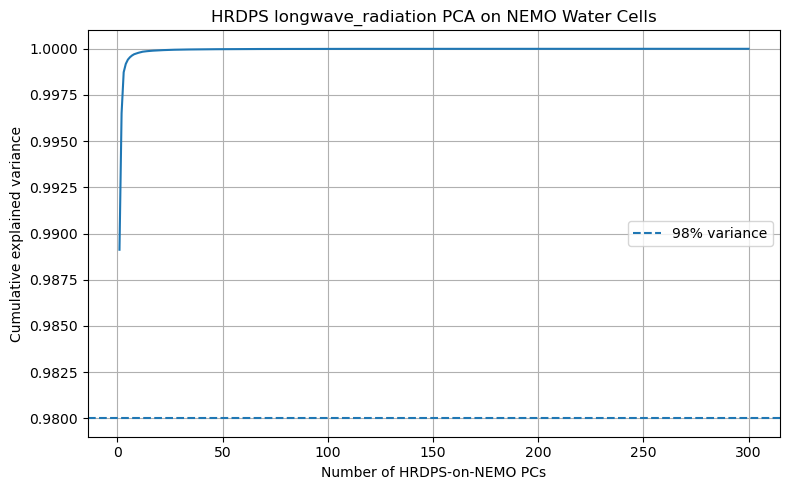

In [102]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(hrdps_cumulative_variance) + 1),hrdps_cumulative_variance)
plt.axhline(hrdps_variance_threshold,linestyle="--",label="98% variance")
plt.xlabel("Number of HRDPS-on-NEMO PCs")
plt.ylabel("Cumulative explained variance")
plt.title("HRDPS longwave_radiation PCA on NEMO Water Cells")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [103]:
threshold_indices = np.where(hrdps_cumulative_variance >= hrdps_variance_threshold)[0]
n_hrdps_pcs = threshold_indices[0] + 1
n_hrdps_pcs = 5
print("Selected HRDPS PCs:", n_hrdps_pcs)
print("Cumulative variance:",hrdps_cumulative_variance[n_hrdps_pcs - 1])

Selected HRDPS PCs: 5
Cumulative variance: 0.9994135


In [104]:
hrdps_train_scores = hrdps_train_scores_all[:, :n_hrdps_pcs]
hrdps_val_scores = pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs]
hrdps_test_scores = pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_pcs]

print("HRDPS train scores:", hrdps_train_scores.shape)
print("HRDPS val scores:  ", hrdps_val_scores.shape)
print("HRDPS test scores: ", hrdps_test_scores.shape)

HRDPS train scores: (26272, 5)
HRDPS val scores:   (8744, 5)
HRDPS test scores:  (8760, 5)


In [105]:
max_canrcm_pcs = min(100,X_canrcm_train.shape[0] - 1,X_canrcm_train.shape[1])
pca_canrcm = PCA(n_components=max_canrcm_pcs,svd_solver="randomized",random_state=0)
canrcm_train_scores_all = pca_canrcm.fit_transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
canrcm_test_scores_all = pca_canrcm.transform(X_canrcm_test)
canrcm_cumulative_variance = np.cumsum(pca_canrcm.explained_variance_ratio_)

print("CanRCM PCA components:", pca_canrcm.components_.shape)
print("CanRCM train scores:", canrcm_train_scores_all.shape)
print("CanRCM val scores:  ", canrcm_val_scores_all.shape)
print("CanRCM test scores: ", canrcm_test_scores_all.shape)

CanRCM PCA components: (100, 340)
CanRCM train scores: (26272, 100)
CanRCM val scores:   (8744, 100)
CanRCM test scores:  (8760, 100)


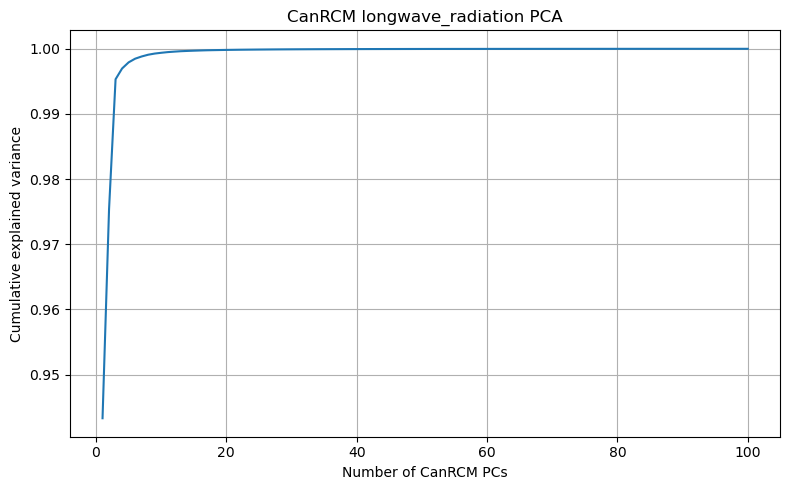

In [106]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(canrcm_cumulative_variance) + 1),canrcm_cumulative_variance)
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Cumulative explained variance")
plt.title("CanRCM longwave_radiation PCA")
plt.grid(True)
plt.tight_layout()
plt.show()

In [107]:
canrcm_pc_candidates = range(1,max_canrcm_pcs + 1)
val_r2_scores = []
for n_canrcm_pcs_candidate in canrcm_pc_candidates:
    X_train_pc = canrcm_train_scores_all[:,:n_canrcm_pcs_candidate]
    X_val_pc = canrcm_val_scores_all[:,:n_canrcm_pcs_candidate]
    model = LinearRegression()
    model.fit(X_train_pc,hrdps_train_scores)
    hrdps_val_scores_pred_candidate = model.predict(X_val_pc)
    val_r2 = r2_score(hrdps_val_scores,hrdps_val_scores_pred_candidate,multioutput="variance_weighted")
    val_r2_scores.append(val_r2)
val_r2_scores = np.array(val_r2_scores)

In [108]:
best_index = np.nanargmax(val_r2_scores)
n_canrcm_pcs = list(canrcm_pc_candidates)[best_index]
best_val_r2 = val_r2_scores[best_index]

print("Best number of CanRCM PCs:", n_canrcm_pcs)
print("Best validation PC-space R²:", best_val_r2)

Best number of CanRCM PCs: 89
Best validation PC-space R²: 0.9625750184059143


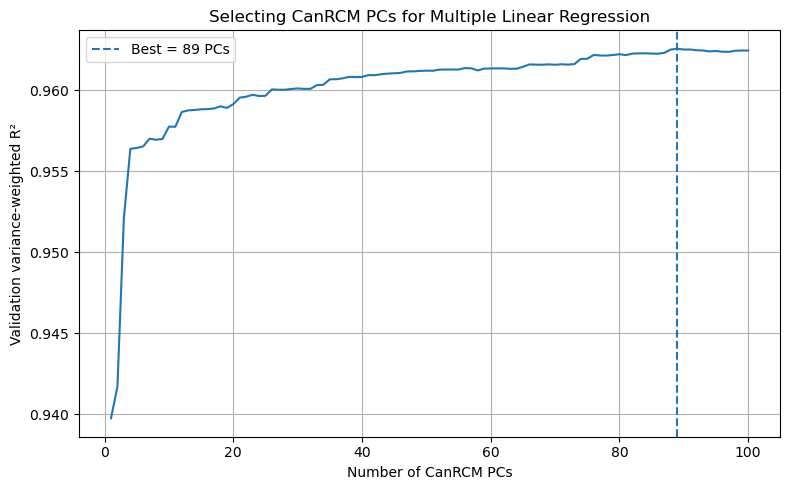

In [109]:
plt.figure(figsize=(8, 5))
plt.plot(list(canrcm_pc_candidates),val_r2_scores)
plt.axvline(n_canrcm_pcs,linestyle="--",label=f"Best = {n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting CanRCM PCs for Multiple Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [110]:
X_train_pc_final = canrcm_train_scores_all[:,:n_canrcm_pcs]
X_val_pc_final = canrcm_val_scores_all[:,:n_canrcm_pcs]
X_test_pc_final = canrcm_test_scores_all[:,:n_canrcm_pcs]
lr_model = LinearRegression()
lr_model.fit(X_train_pc_final,hrdps_train_scores)

hrdps_train_scores_pred = lr_model.predict(X_train_pc_final)
hrdps_val_scores_pred = lr_model.predict(X_val_pc_final)
hrdps_test_scores_pred = lr_model.predict(X_test_pc_final)

print("Regression coefficient shape:", lr_model.coef_.shape)
print("Predicted HRDPS train scores:",hrdps_train_scores_pred.shape)
print("Predicted HRDPS validation scores:",hrdps_val_scores_pred.shape)
print("Predicted HRDPS test scores:",hrdps_test_scores_pred.shape)

Regression coefficient shape: (5, 89)
Predicted HRDPS train scores: (26272, 5)
Predicted HRDPS validation scores: (8744, 5)
Predicted HRDPS test scores: (8760, 5)


In [111]:
def inverse_from_selected_hrdps_pcs(scores, pca, n_pcs):
    reconstructed = np.dot(scores,pca.components_[:n_pcs, :])
    reconstructed = reconstructed + pca.mean_
    return reconstructed.astype(np.float32)

In [112]:
X_hrdps_val_pred = inverse_from_selected_hrdps_pcs(hrdps_val_scores_pred,pca_hrdps,n_hrdps_pcs)
X_hrdps_test_pred = inverse_from_selected_hrdps_pcs(hrdps_test_scores_pred,pca_hrdps,n_hrdps_pcs)
print("Actual validation matrix:", X_hrdps_val.shape)
print("Predicted validation matrix:", X_hrdps_val_pred.shape)
print("Actual test matrix:", X_hrdps_test.shape)
print("Predicted test matrix:", X_hrdps_test_pred.shape)

Actual validation matrix: (8744, 81383)
Predicted validation matrix: (8744, 81383)
Actual test matrix: (8760, 81383)
Predicted test matrix: (8760, 81383)


In [113]:
def calculate_metrics(actual, predicted, label):
    rmse = np.sqrt(mean_squared_error(actual.ravel(),predicted.ravel()))
    mae = mean_absolute_error(actual.ravel(),predicted.ravel())
    bias = np.mean(predicted - actual)
    r2 = r2_score(actual,predicted,multioutput="variance_weighted")
    actual_std = np.std(actual, ddof=0)
    normalized_rmse = rmse / actual_std
    print(f"\n{label}")
    print("RMSE:", rmse, "K")
    print("MAE: ", mae, "K")
    print("Bias:", bias, "K")
    print("R²:  ", r2)
    print("Actual standard deviation:", actual_std, "K")
    print("Normalized RMSE:", normalized_rmse)
    print("Normalized RMSE (%):", normalized_rmse * 100)
    return {"RMSE": rmse,"MAE": mae,"Bias": bias,"R2": r2, "Normalized_RMSE": normalized_rmse,"Normalized_RMSE_percent": normalized_rmse * 100}

In [114]:
val_metrics = calculate_metrics(X_hrdps_val, X_hrdps_val_pred, "Validation metrics on NEMO water cells")
test_metrics = calculate_metrics(X_hrdps_test,X_hrdps_test_pred,"Test metrics on NEMO water cells")


Validation metrics on NEMO water cells
RMSE: 158.18227717573166 K
MAE:  115.12470245361328 K
Bias: 17.65731 K
R²:   0.961930513381958
Actual standard deviation: 811.38293 K
Normalized RMSE: 0.1949539119398671
Normalized RMSE (%): 19.495391193986713

Test metrics on NEMO water cells
RMSE: 124.82082079800429 K
MAE:  90.32817077636719 K
Bias: 10.764552 K
R²:   0.9700532555580139
Actual standard deviation: 721.79895 K
Normalized RMSE: 0.17293017780675474
Normalized RMSE (%): 17.293017780675473


In [115]:
test_pc_r2 = r2_score(hrdps_test_scores,hrdps_test_scores_pred,multioutput="variance_weighted")
print("Test PC-space variance-weighted R²:", test_pc_r2)

Test PC-space variance-weighted R²: 0.9707345366477966


In [116]:
def nemo_vector_to_map(vector):
    nemo_map = np.full(water_mask.shape,np.nan,dtype=np.float32)
    nemo_map[valid_nemo_j,valid_nemo_i] = vector
    return nemo_map

In [117]:
def plot_actual_predicted_error(time_index,X_actual,X_predicted,times):
    actual_map = nemo_vector_to_map(X_actual[time_index])
    predicted_map = nemo_vector_to_map(X_predicted[time_index])
    error_map = predicted_map - actual_map
    longwave_radiation_min = np.nanmin(np.stack([actual_map, predicted_map]))
    longwave_radiation_max = np.nanmax(np.stack([actual_map, predicted_map]))
    error_limit = np.nanmax(np.abs(error_map))
    timestamp = pd.Timestamp(times[time_index])
    fig, axes = plt.subplots(1,3,figsize=(18, 8))

    p0 = axes[0].pcolormesh(actual_map,shading="auto",vmin=longwave_radiation_min,vmax=longwave_radiation_max)
    axes[0].set_title(f"Actual HRDPS on NEMO Grid\n{timestamp}")
    plt.colorbar(p0,ax=axes[0],label="longwave_radiation (K)")

    p1 = axes[1].pcolormesh(predicted_map,shading="auto",vmin=longwave_radiation_min,vmax=longwave_radiation_max )
    axes[1].set_title(f"Predicted PCA + MLR\n{timestamp}")
    plt.colorbar(p1,ax=axes[1],label="longwave_radiation (K)")

    p2 = axes[2].pcolormesh(error_map,shading="auto",cmap="RdBu_r",vmin=-error_limit,vmax=error_limit)
    axes[2].set_title(f"Predicted − Actual\n{timestamp}")
    plt.colorbar(p2,ax=axes[2],label="Error (K)")

    for ax in axes:
        ax.set_xlabel("NEMO x index (i)")
        ax.set_ylabel("NEMO y index (j)")

    plt.tight_layout()
    plt.show()

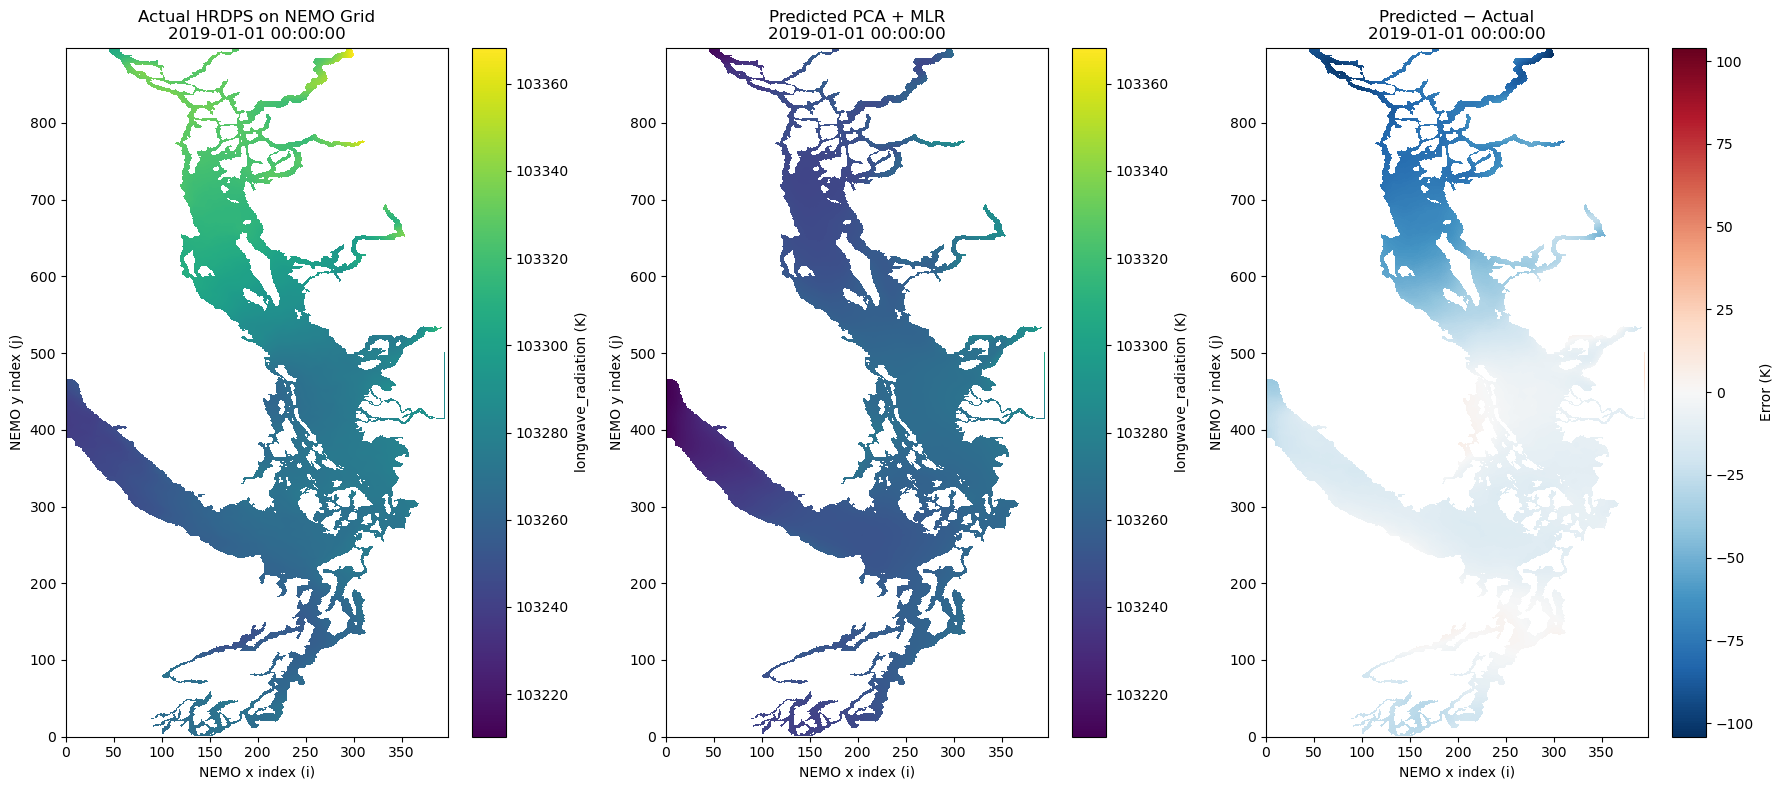

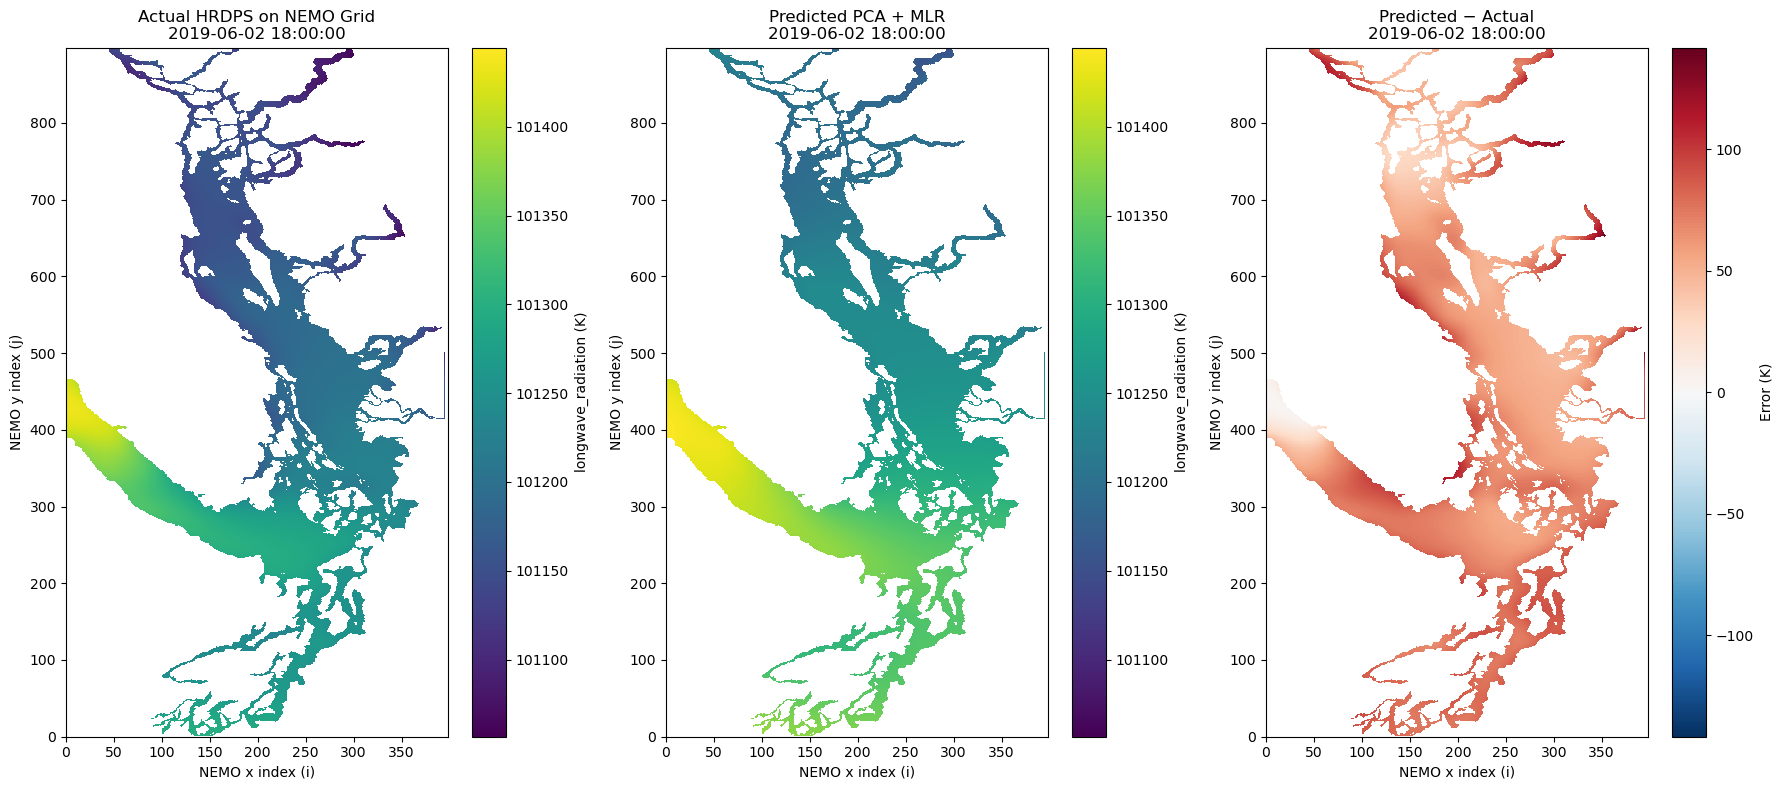

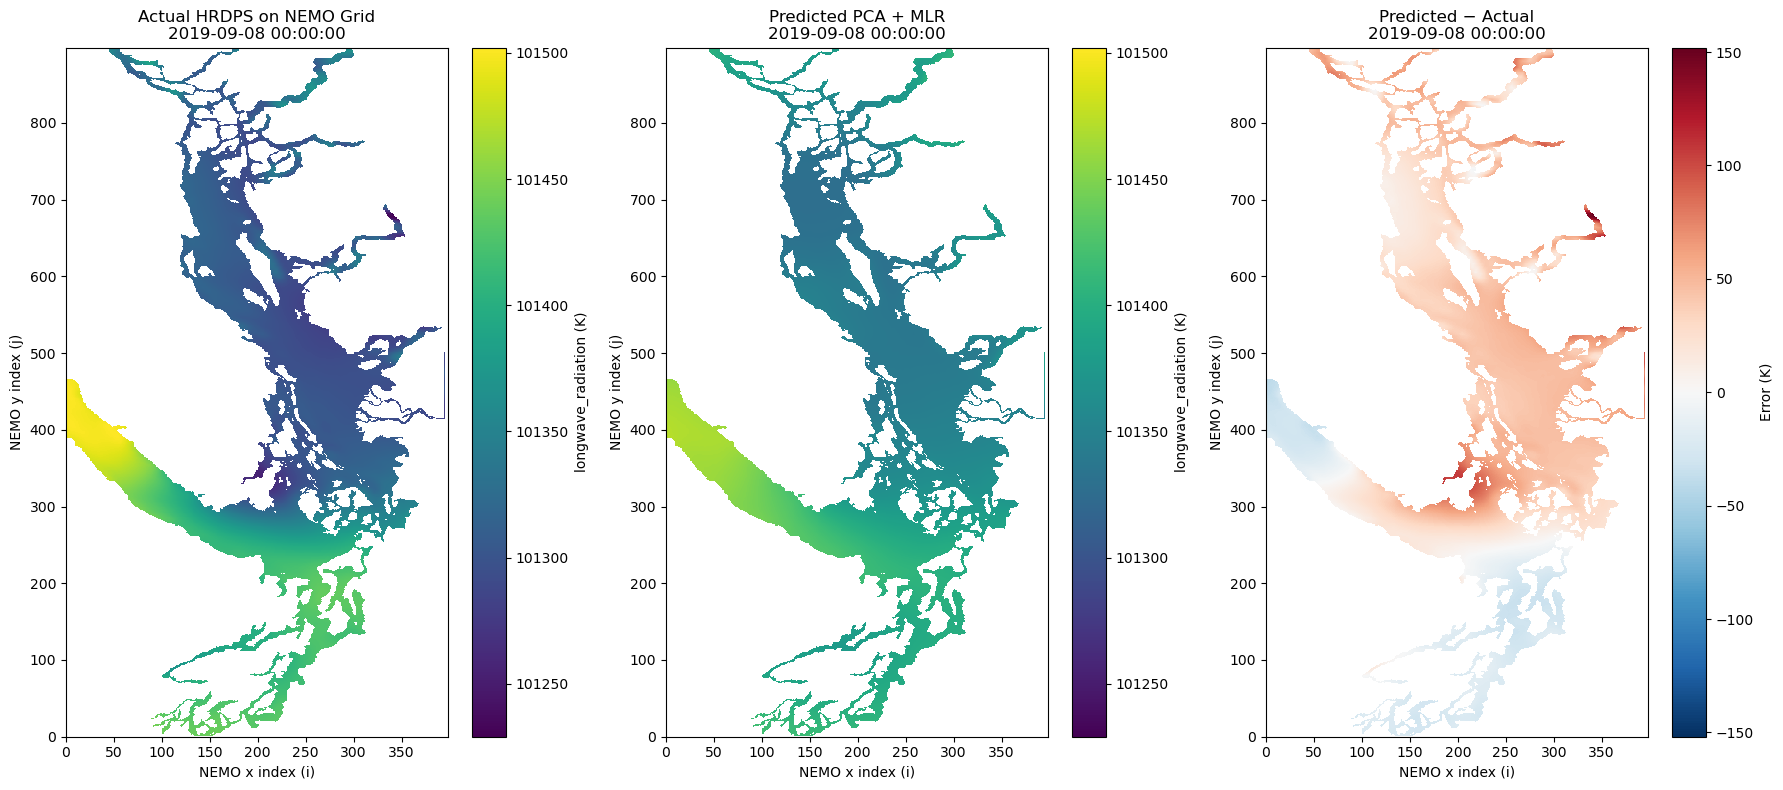

In [118]:
test_times = ds_hrdps_test["time_counter"].values

plot_actual_predicted_error(
    time_index=0,
    X_actual=X_hrdps_test,
    X_predicted=X_hrdps_test_pred,
    times=test_times
)

plot_actual_predicted_error(
    time_index=1222,
    X_actual=X_hrdps_test,
    X_predicted=X_hrdps_test_pred,
    times=test_times
)

plot_actual_predicted_error(
    time_index=2000,
    X_actual=X_hrdps_test,
    X_predicted=X_hrdps_test_pred,
    times=test_times
)

In [119]:
def make_spatial_mean_timeseries(actual_matrix,predicted_matrix,times):
    actual_mean = np.mean(actual_matrix,axis=1)
    predicted_mean = np.mean(predicted_matrix,axis=1)
    timeseries = pd.DataFrame({"actual": actual_mean,"predicted": predicted_mean},index=pd.to_datetime(times))
    timeseries.index.name = "Date"
    return timeseries

In [120]:
val_times = ds_hrdps_val["time_counter"].values
test_times = ds_hrdps_test["time_counter"].values

longwave_radiation_timeseries_2007 = make_spatial_mean_timeseries(
    actual_matrix=X_hrdps_val,
    predicted_matrix=X_hrdps_val_pred,
    times=val_times
)

longwave_radiation_timeseries_2019 = make_spatial_mean_timeseries(
    actual_matrix=X_hrdps_test,
    predicted_matrix=X_hrdps_test_pred,
    times=test_times
)

print(longwave_radiation_timeseries_2007.head())
print()
print(longwave_radiation_timeseries_2019.head())

                            actual      predicted
Date                                             
2007-01-03 00:00:00  100323.992188  100193.414062
2007-01-03 03:00:00  100389.757812  100319.578125
2007-01-03 06:00:00  100489.929688  100398.992188
2007-01-03 09:00:00  100580.640625  100372.406250
2007-01-03 12:00:00  100444.945312  100307.656250

                            actual      predicted
Date                                             
2019-01-01 00:00:00  103279.992188  103254.554688
2019-01-01 03:00:00  103244.820312  103174.664062
2019-01-01 06:00:00  103168.765625  103124.750000
2019-01-01 09:00:00  103157.539062  103092.445312
2019-01-01 12:00:00  103048.398438  103118.195312


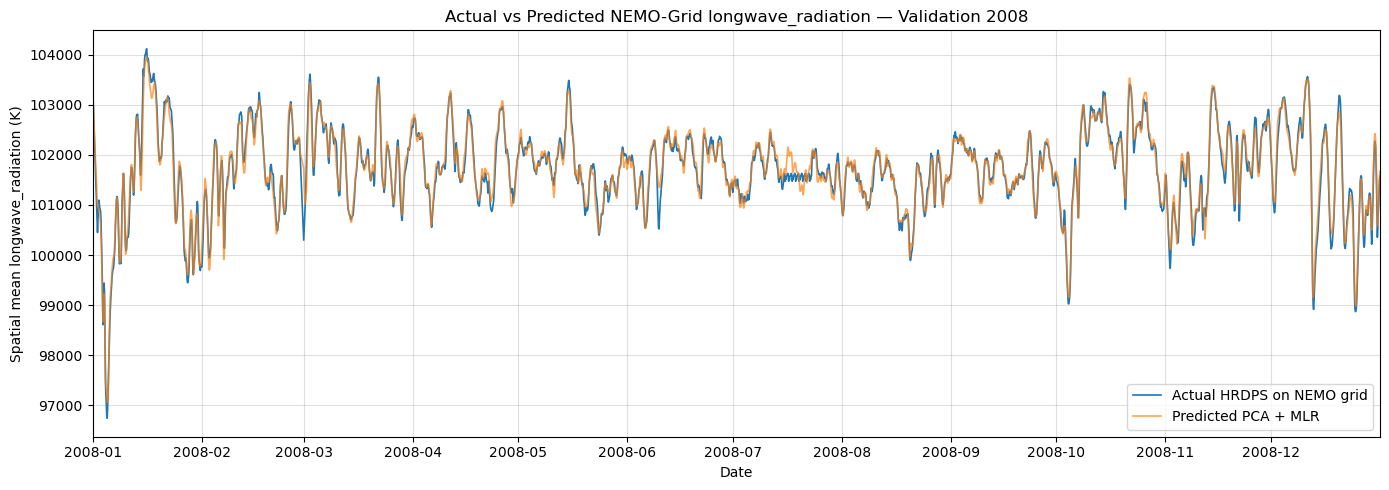

In [121]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(longwave_radiation_timeseries_2007.index,longwave_radiation_timeseries_2007["actual"],label="Actual HRDPS on NEMO grid",linewidth=1.2)
ax.plot(longwave_radiation_timeseries_2007.index,longwave_radiation_timeseries_2007["predicted"],label="Predicted PCA + MLR",linewidth=1.2,alpha=0.7)
ax.set_xlim(pd.Timestamp("2008-01-01"),pd.Timestamp("2008-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean longwave_radiation (K)")
ax.set_title("Actual vs Predicted NEMO-Grid longwave_radiation — Validation 2008")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

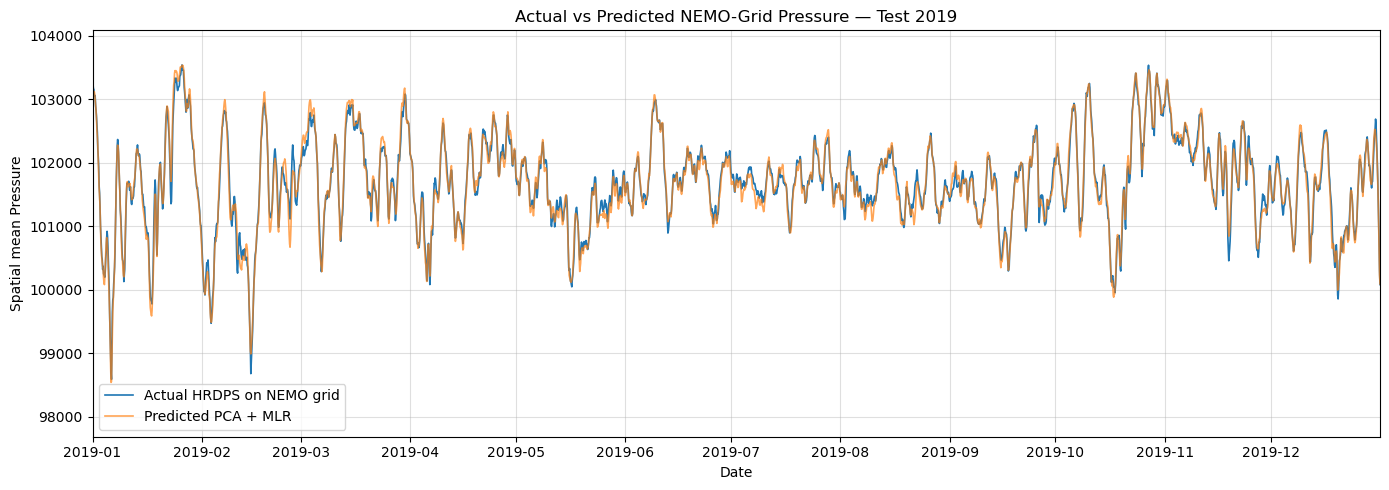

In [122]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(longwave_radiation_timeseries_2019.index, longwave_radiation_timeseries_2019["actual"], label="Actual HRDPS on NEMO grid", linewidth=1.2)
ax.plot(longwave_radiation_timeseries_2019.index, longwave_radiation_timeseries_2019["predicted"], label="Predicted PCA + MLR", linewidth=1.2, alpha=0.7)

ax.set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2019-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean Pressure")
ax.set_title("Actual vs Predicted NEMO-Grid Pressure — Test 2019")
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [123]:
stations = {"Sand Heads": {"j": 426,"i": 293},
    "Halibut Bank": {"j": 503,"i": 261},
    "Sentry Shoal": {"j": 707,"i": 145}}

In [124]:
def find_station_column(station_j, station_i):
    matches = np.where((valid_nemo_j == station_j)& (valid_nemo_i == station_i))[0]
    return int(matches[0])

for station_name, station_info in stations.items():
    column = find_station_column(station_info["j"],station_info["i"])
    stations[station_name]["column"] = column
    print(station_name,"j =", station_info["j"],"i =", station_info["i"],"matrix column =", column)

Sand Heads j = 426 i = 293 matrix column = 44165
Halibut Bank j = 503 i = 261 matrix column = 53329
Sentry Shoal j = 707 i = 145 matrix column = 71870


In [125]:
test_times = pd.to_datetime(ds_hrdps_test["time_counter"].values)
station_timeseries = {}
station_rmse = {}
station_normalized_rmse = {}

for station_name, station_info in stations.items():
    column = station_info["column"]

    actual = X_hrdps_test[:, column]
    predicted = X_hrdps_test_pred[:, column]

    station_df = pd.DataFrame({"actual": actual,"predicted": predicted},index=test_times)
    station_df.index.name = "Date"
    rmse = np.sqrt(mean_squared_error(station_df["actual"],station_df["predicted"]))
    actual_std = np.std(station_df["actual"],ddof=0)
    normalized_rmse = rmse / actual_std
    station_timeseries[station_name] = station_df
    station_rmse[station_name] = rmse
    station_normalized_rmse[station_name] = normalized_rmse
    print(f"{station_name} RMSE: {rmse:.4f} ")
    print(f"{station_name} Normalized RMSE: {normalized_rmse:.4f} ({normalized_rmse * 100:.2f}%)")

Sand Heads RMSE: 124.7409 
Sand Heads Normalized RMSE: 0.1744 (17.44%)
Halibut Bank RMSE: 126.0046 
Halibut Bank Normalized RMSE: 0.1744 (17.44%)
Sentry Shoal RMSE: 130.9272 
Sentry Shoal Normalized RMSE: 0.1741 (17.41%)


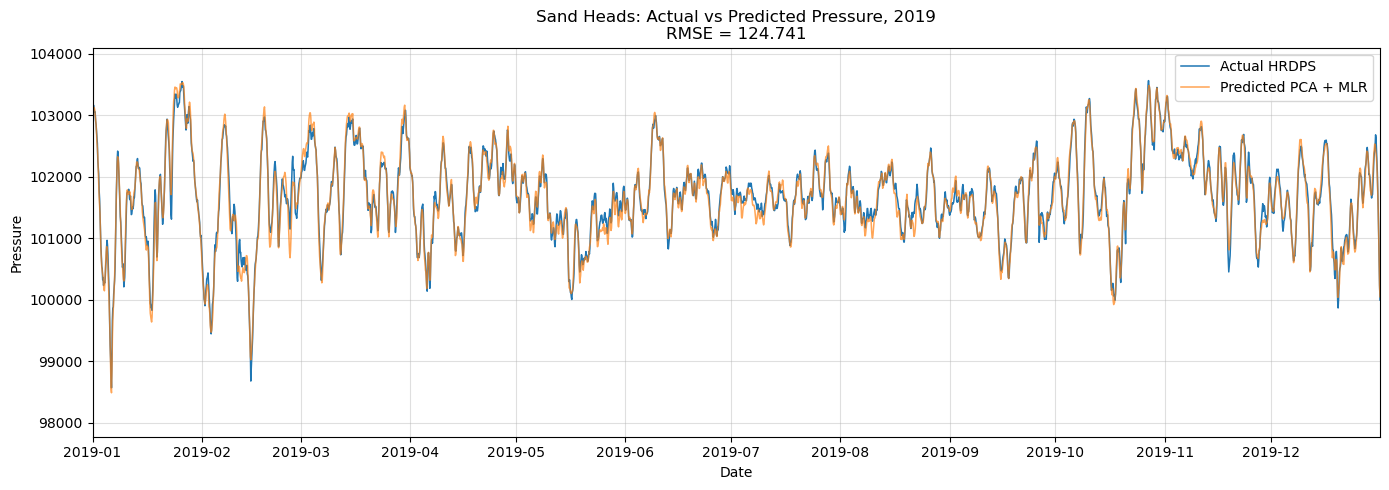

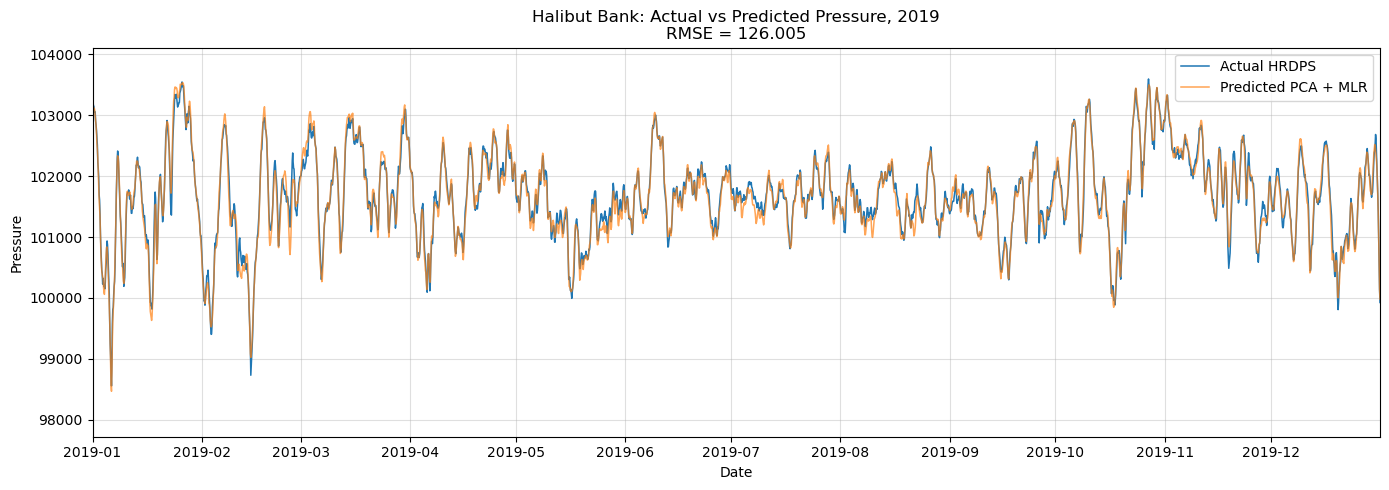

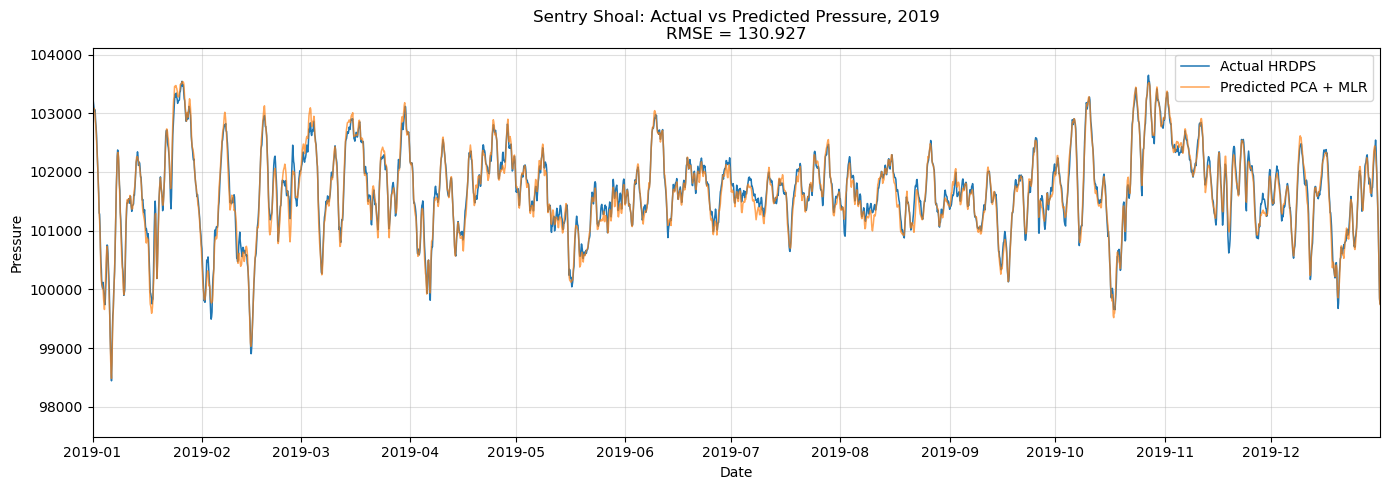

In [126]:
for station_name, station_df in station_timeseries.items():
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(station_df.index, station_df["actual"], label="Actual HRDPS", linewidth=1.1)
    ax.plot(station_df.index, station_df["predicted"], label="Predicted PCA + MLR", linewidth=1.1, alpha=0.7)
    ax.set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2019-12-31 23:59:59"))
    ax.set_xlabel("Date")
    ax.set_ylabel("Pressure")
    ax.set_title(f"{station_name}: Actual vs Predicted Pressure, 2019\nRMSE = {station_rmse[station_name]:.3f}")
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

In [127]:
station_rmse_table = pd.DataFrame({"Station": list(station_rmse.keys()),"RMSE_K": list(station_rmse.values()),"Normalized_RMSE": list(station_normalized_rmse.values())})
station_rmse_table["Normalized_RMSE_Percent"] = station_rmse_table["Normalized_RMSE"] * 100
average_station_rmse = station_rmse_table["RMSE_K"].mean()
average_station_normalized_rmse = station_rmse_table["Normalized_RMSE"].mean()
print(station_rmse_table.to_string(index=False))
print(f"\nAverage RMSE across the three stations: {average_station_rmse:.4f}")
print(f"Average normalized RMSE across the three stations: {average_station_normalized_rmse:.4f} ({average_station_normalized_rmse * 100:.2f}%)")

     Station     RMSE_K  Normalized_RMSE  Normalized_RMSE_Percent
  Sand Heads 124.740880         0.174362                17.436200
Halibut Bank 126.004573         0.174377                17.437744
Sentry Shoal 130.927192         0.174075                17.407495

Average RMSE across the three stations: 127.2242
Average normalized RMSE across the three stations: 0.1743 (17.43%)


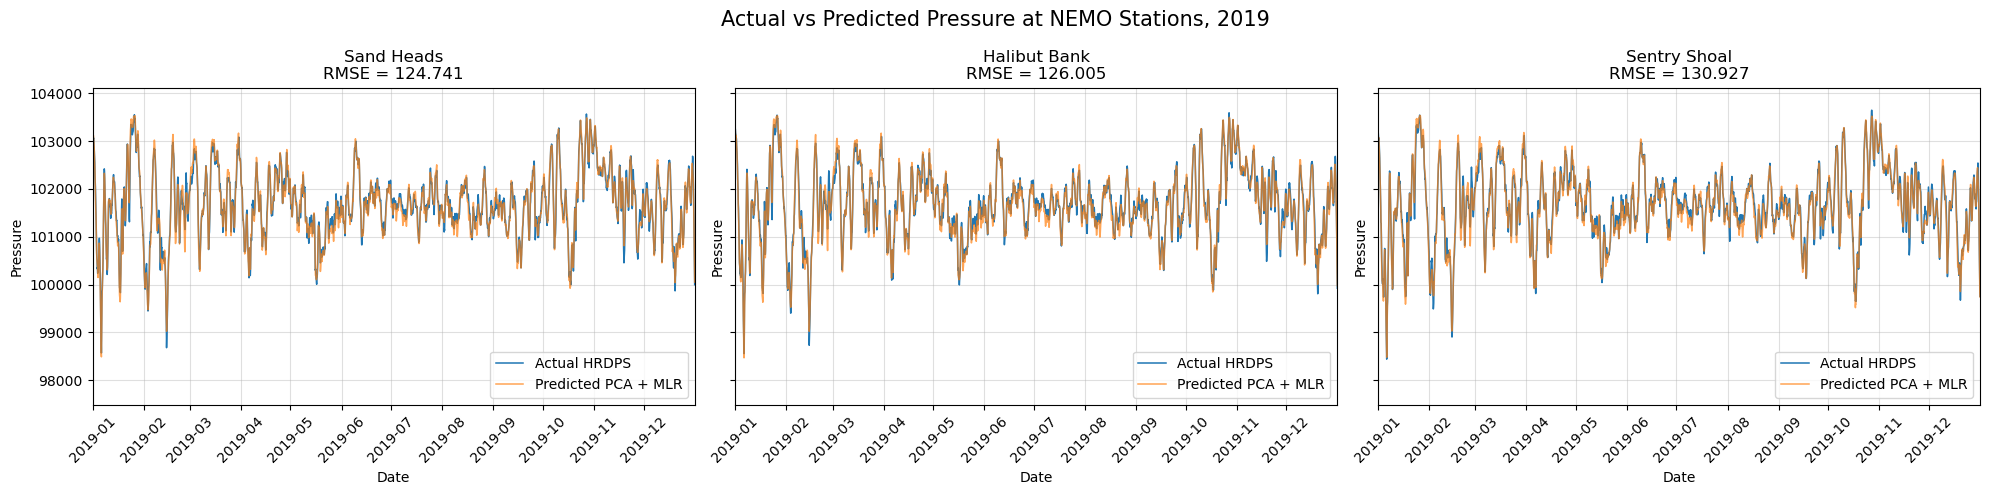

In [128]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, (station_name, station_df) in zip(axes, station_timeseries.items()):
    ax.plot(station_df.index, station_df["actual"], label="Actual HRDPS", linewidth=1.1)
    ax.plot(station_df.index, station_df["predicted"], label="Predicted PCA + MLR", linewidth=1.1, alpha=0.7)
    ax.set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2019-12-31 23:59:59"))
    ax.set_xlabel("Date")
    ax.set_ylabel("Pressure")
    ax.set_title(f"{station_name}\nRMSE = {station_rmse[station_name]:.3f}")
    ax.legend()
    ax.grid(True, alpha=0.4)
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("Actual vs Predicted Pressure at NEMO Stations, 2019", fontsize=15)

plt.tight_layout()
plt.show()